In [ ]:
import sys, os
sys.path.append("../bess-optimizer")

from optimizer import optimizer
from matplotlib import pyplot as plt
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from scipy.stats import mannwhitneyu

In [ ]:
df = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'day_ahead_prices.csv'), index_col=0, parse_dates=True)
df = df.values.repeat(4, axis=1)
df = pd.DataFrame(df).iloc[1:]

df_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'predictions.csv'), index_col=0, parse_dates=True)
df_results = df_results.values.repeat(4, axis=1)
df_results = pd.DataFrame(df_results).iloc[1:]

df_pca_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'pca_predictions.csv'), index_col=0, parse_dates=True)
df_pca_results = df_pca_results.values.repeat(4, axis=1)
df_pca_results = pd.DataFrame(df_pca_results).iloc[1:]

df_naive = df.shift(1).dropna()

intersect_index = df.index.intersection(df_results.index).intersection(df_pca_results.index).intersection(df_naive.index)
df = df.loc[intersect_index]
df_results = df_results.loc[intersect_index]
df_pca_results = df_pca_results.loc[intersect_index]
df_naive = df_naive.loc[intersect_index]

In [ ]:
# get predictions
ica_pred_vector = df_results.iloc[0].values
pca_pred_vector = df_pca_results.iloc[0].values
naive_pred_vector = df_naive.iloc[0].values

actual_vector = df.iloc[0].values

# optimize battery on day-ahead predictions
energy_cap = 2
power_cap = 1
n_cycles = 1.5

solverpath_exe = '/usr/bin/glpsol'

In [ ]:
optimizer_flex = optimizer(solverpath_exe=solverpath_exe)

In [ ]:
profit_data = {}
# ica results
step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=ica_pred_vector)
revenue_daa_ica = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
profit_data['ica'] = step1_profit_daa

# pca results
step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=pca_pred_vector)
revenue_daa_pca = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
profit_data['pca'] = step1_profit_daa

# naive results
step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=naive_pred_vector)
revenue_daa_naive = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
profit_data['naive'] = step1_profit_daa

# benchmark results (actual prices)
step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=actual_vector)
revenue_daa_naive = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
profit_data['benchmark'] = step1_profit_daa

In [ ]:
def optimize_one_day(pred_vector, actual_vector, energy_cap=2, power_cap=1, n_cycles=1.5):
    step1_soc_daa,step1_cha_daa,step1_dis_daa, step1_profit_daa = optimizer_flex.step1_optimize_daa(n_cycles=n_cycles, energy_cap=energy_cap, power_cap=power_cap, daa_price_vector=pred_vector)
    revenue_daa = np.sum(np.asarray(actual_vector) * (np.asarray(step1_dis_daa) - step1_cha_daa)) * power_cap/4
    return revenue_daa

In [ ]:
df_revenues = pd.DataFrame(index=df.index, columns=['ica', 'pca', 'naive', 'benchmark'])
ica_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_results.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_results))))
df_revenues['ica'] = ica_revenues

100%|██████████| 2045/2045 [00:02<00:00, 977.63it/s] 


In [ ]:
pca_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_pca_results.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_pca_results))))
df_revenues['pca'] = pca_revenues

100%|██████████| 2045/2045 [00:01<00:00, 1277.70it/s]


In [ ]:
naive_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df_naive.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df_naive))))
df_revenues['naive'] = naive_revenues

100%|██████████| 2045/2045 [00:01<00:00, 1307.65it/s]


In [ ]:
benchmark_revenues = Parallel(n_jobs=-1)(delayed(optimize_one_day)(df.iloc[i].values, df.iloc[i].values) for i in tqdm(range(len(df))))
df_revenues['benchmark'] = benchmark_revenues

100%|██████████| 2045/2045 [00:01<00:00, 1292.77it/s]


<Axes: >

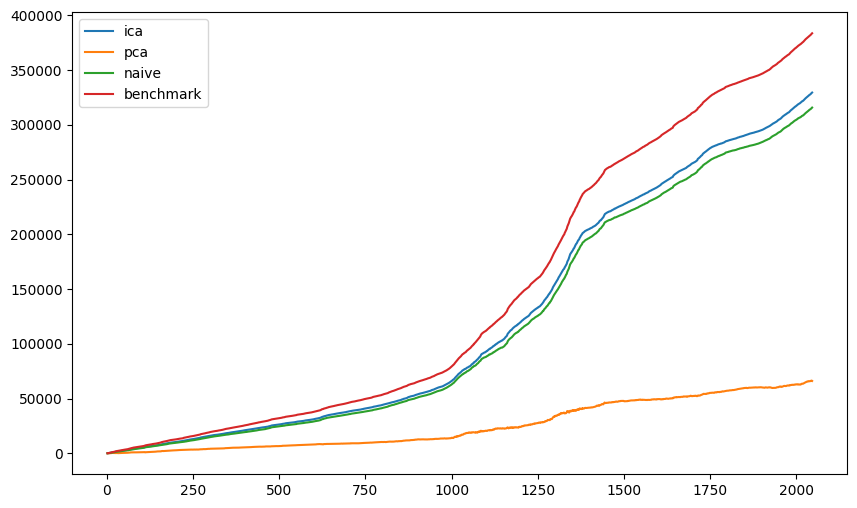

In [ ]:
df_revenues.cumsum().plot(figsize=(10,6))

array([[<Axes: title={'center': 'ica'}>, <Axes: title={'center': 'pca'}>],
       [<Axes: title={'center': 'naive'}>,
        <Axes: title={'center': 'benchmark'}>]], dtype=object)

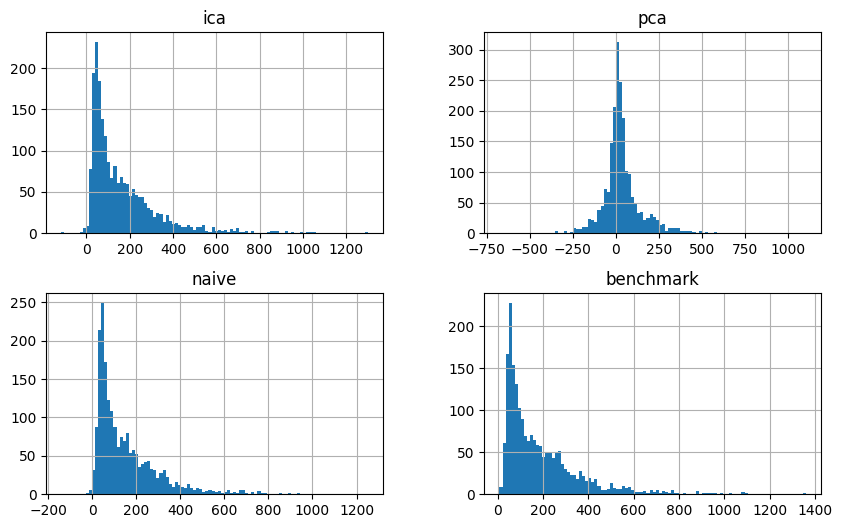

In [ ]:
df_revenues.hist(bins=100, figsize=(10,6))

<Axes: >

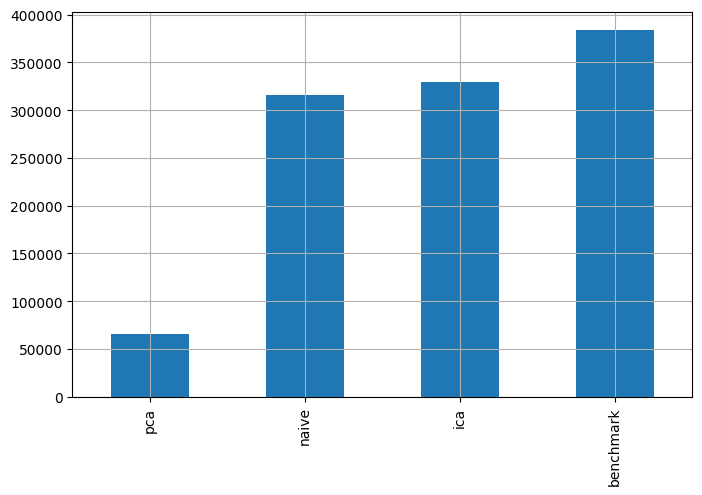

In [ ]:
df_revenues.sum().sort_values().plot.bar(figsize=(8,5), grid=True)

In [ ]:
print("ICA vs PCA p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['pca'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['pca'].sum()) / abs(df_revenues['pca'].sum()), 4))
print("ICA vs Naive p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['naive'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['naive'].sum()) / abs(df_revenues['naive'].sum()), 4))
print("ICA vs Benchmark p-value:", round(mannwhitneyu(df_revenues['ica'], df_revenues['benchmark'], alternative="greater").pvalue, 4), "relative difference:", round((df_revenues['ica'].sum() - df_revenues['benchmark'].sum()) / abs(df_revenues['benchmark'].sum()), 4))

ICA vs PCA p-value: 0.0 relative difference: 3.9863
ICA vs Naive p-value: 0.0256 relative difference: 0.0435
ICA vs Benchmark p-value: 1.0 relative difference: -0.1411
